## Introduction to Clustering with the Iris Dataset

In this notebook, we will explore clustering techniques using the famous Iris dataset. We'll aim to group the iris flowers into distinct clusters based on their features.

Next, we use a pairplot visualize the relationships between all pairs of features in the Iris dataset, colored by species. It gives a good initial understanding of how different species cluster based on these measurements.


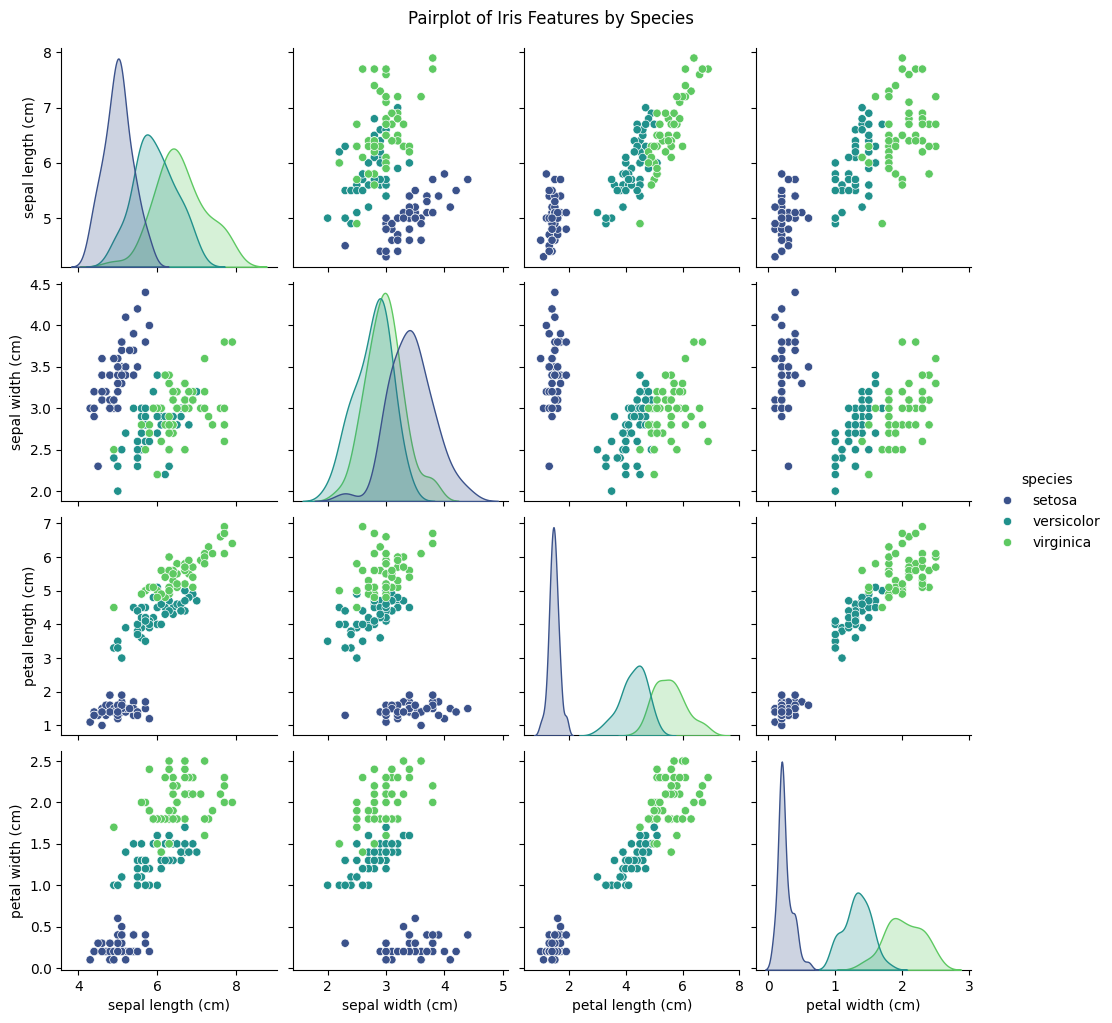

In [ ]:
from sklearn import datasets
iris = datasets.load_iris()

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Convert to a pandas DataFrame for easier plotting
iris_df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
iris_df['species'] = iris.target_names[iris.target]

# Create a pairplot
sns.pairplot(iris_df, hue='species', palette='viridis')
plt.suptitle('Pairplot of Iris Features by Species', y=1.02) # Add a title to the plot
plt.show()

### K-means Clustering

Let's visualize the clustering results to compare them with the actual species. We will create a pairplot, but this time, the data points will be colored according to their assigned K-Means cluster.

Recall, the k-means algorithm attempts to minimize the within-cluster sum of squares distance

$$ \min_{\mu_j} \sum_{j=1}^k \sum_{x_n\in C_j} \|x_n-\mu_j\|^2 $$

where $\mu_j$ denotes the jth cluster and $C_j$ denotes the subdomain (Voronoi cell) of data associated with that cluster. This problem as posed in NP-hard, but can tractably be solved with Lloyd's algorithm, which guesses the numner of clusters and initial cluster means or _centroids_.

In [ ]:
from sklearn.cluster import KMeans
import numpy as np

# Extract features from iris_df into a NumPy array
X = iris_df.drop('species', axis=1).values

# Initialize and train K-Means model with 3 clusters
kmeans = KMeans(n_clusters=3, random_state=42, n_init='auto')
kmeans.fit(X)

# Add cluster labels to the original DataFrame
iris_df['cluster'] = kmeans.labels_
display(iris_df.head())

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species,cluster,dbscan_cluster,optics_cluster
0,5.1,3.5,1.4,0.2,setosa,1,0,0
1,4.9,3.0,1.4,0.2,setosa,1,0,0
2,4.7,3.2,1.3,0.2,setosa,1,0,0
3,4.6,3.1,1.5,0.2,setosa,1,0,0
4,5.0,3.6,1.4,0.2,setosa,1,0,0


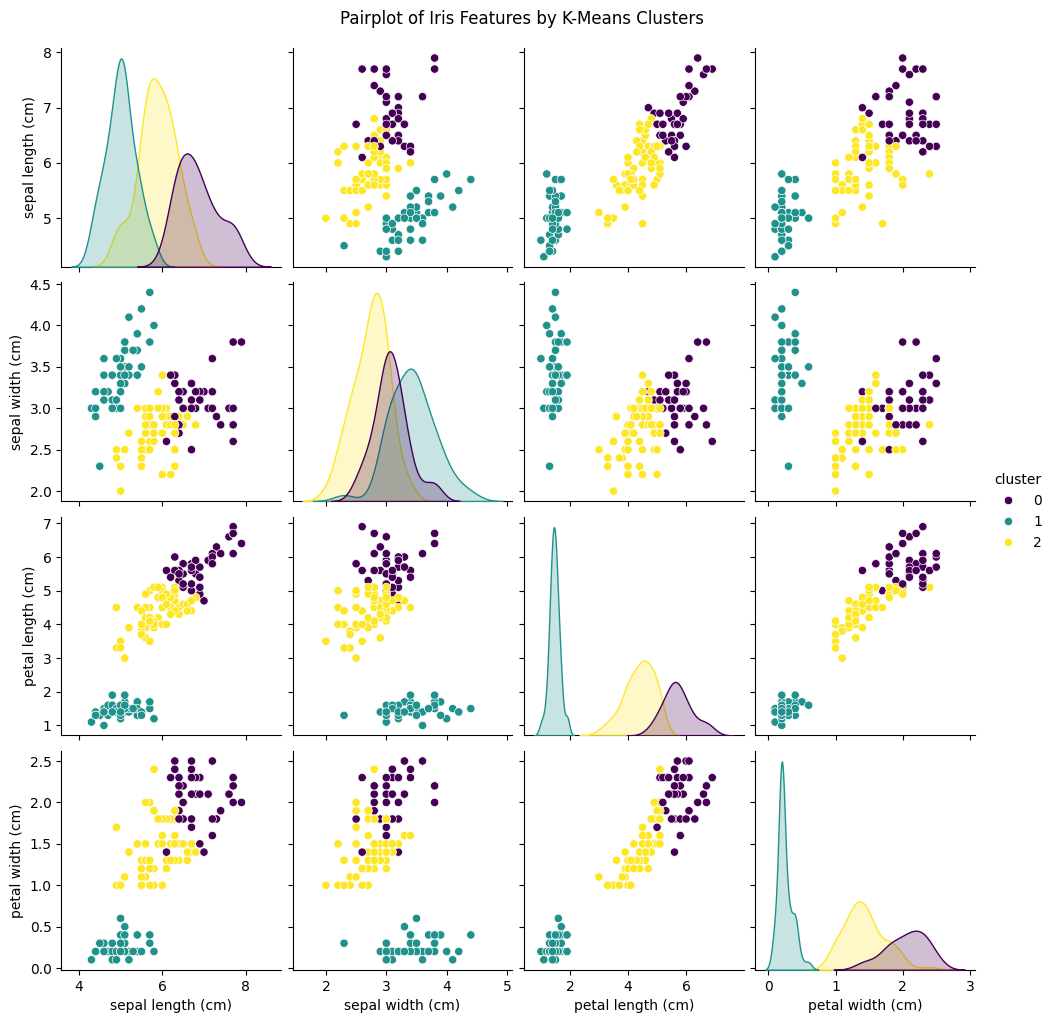

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.pairplot(iris_df, hue='cluster', palette='viridis')
plt.suptitle('Pairplot of Iris Features by K-Means Clusters', y=1.02)
plt.show()

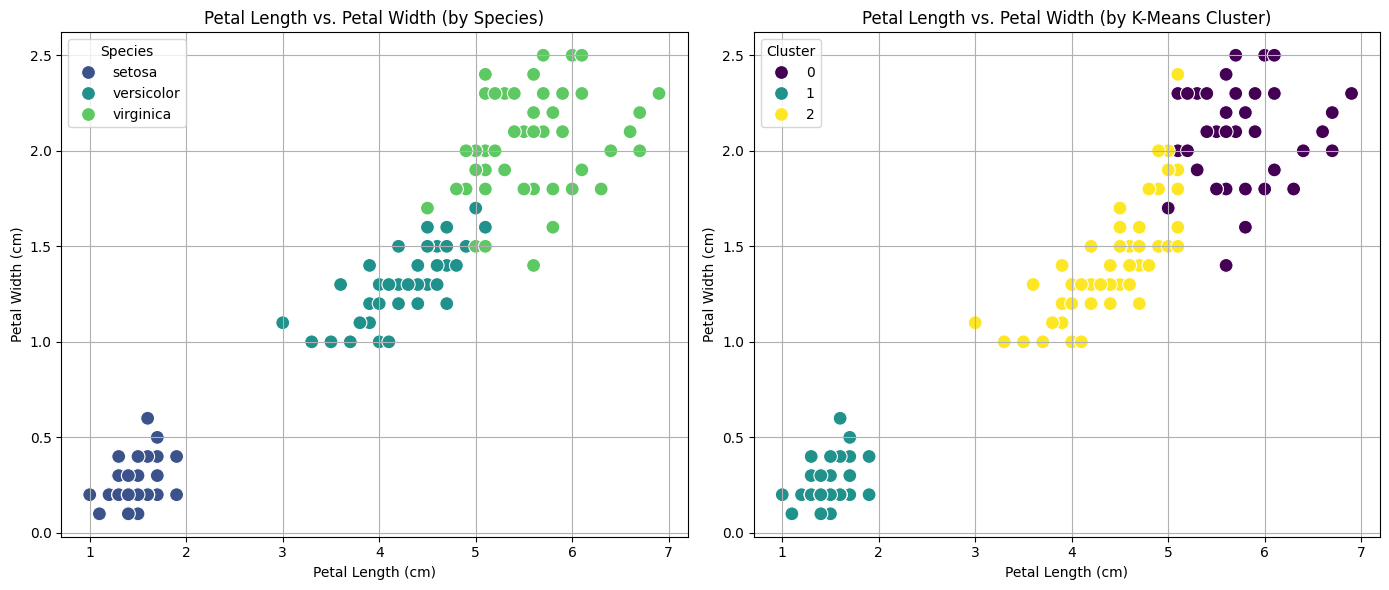

(150, 6)


In [ ]:
plt.figure(figsize=(14, 6))

# Subplot 1: Petal width vs. Petal length, colored by actual species
plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
sns.scatterplot(data=iris_df, x='petal length (cm)', y='petal width (cm)', hue='species', palette='viridis', s=100)
plt.title('Petal Length vs. Petal Width (by Species)')
plt.xlabel('Petal Length (cm)')
plt.ylabel('Petal Width (cm)')
plt.legend(title='Species')
plt.grid(True)

# Subplot 2: Petal width vs. Petal length, colored by K-Means cluster
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
sns.scatterplot(data=iris_df, x='petal length (cm)', y='petal width (cm)', hue='cluster', palette='viridis', s=100)
plt.title('Petal Length vs. Petal Width (by K-Means Cluster)')
plt.xlabel('Petal Length (cm)')
plt.ylabel('Petal Width (cm)')
plt.legend(title='Cluster')
plt.grid(True)

plt.tight_layout()
plt.show()


### DBSCAN Clustering

Unlike K-Means, DBSCAN (Density-Based Spatial Clustering of Applications with Noise) does not require the number of clusters to be specified beforehand. Instead, it groups together data points that are closely packed together, marking as outliers those points that lie alone in low-density regions. DBSCAN relies on two main parameters:

*   `eps`: The maximum distance between two samples for one to be considered as in the neighborhood of the other.
*   `min_samples`: The number of samples (or total weight) in a neighborhood for a point to be considered as a core point. This includes the point itself.

Points are classified as:
*   **Core point:** A point with at least `min_samples` points (including itself) within distance `eps`.
*   **Border point:** A point that has fewer than `min_samples` points within `eps`, but is in the neighborhood of a core point.
*   **Noise point:** A point that is neither a core point nor a border point. These are assigned a cluster label of -1.

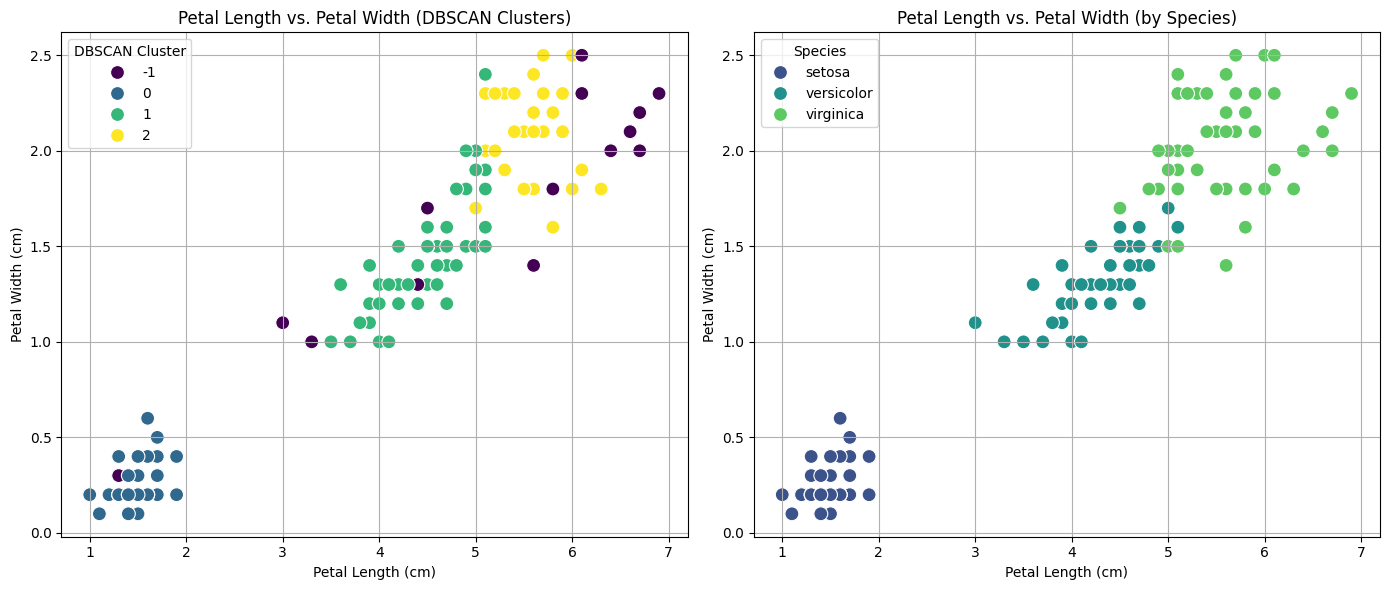

In [ ]:
from sklearn.cluster import DBSCAN

plt.figure(figsize=(14, 6))

# Apply DBSCAN clustering to the feature matrix X
dbscan = DBSCAN(eps=0.5, min_samples=5) # These parameters may need tuning
dbscan_labels = dbscan.fit_predict(X)

# Add DBSCAN cluster labels to the DataFrame
iris_df['dbscan_cluster'] = dbscan_labels

# Visualize the DBSCAN clustering results
plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
sns.scatterplot(data=iris_df, x='petal length (cm)', y='petal width (cm)', hue='dbscan_cluster', palette='viridis', s=100)
plt.title('Petal Length vs. Petal Width (DBSCAN Clusters)')
plt.xlabel('Petal Length (cm)')
plt.ylabel('Petal Width (cm)')
plt.legend(title='DBSCAN Cluster')
plt.grid(True)

# Subplot 2: Petal width vs. Petal length, colored by actual species
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
sns.scatterplot(data=iris_df, x='petal length (cm)', y='petal width (cm)', hue='species', palette='viridis', s=100)
plt.title('Petal Length vs. Petal Width (by Species)')
plt.xlabel('Petal Length (cm)')
plt.ylabel('Petal Width (cm)')
plt.legend(title='Species')
plt.grid(True)

plt.tight_layout()
plt.show()

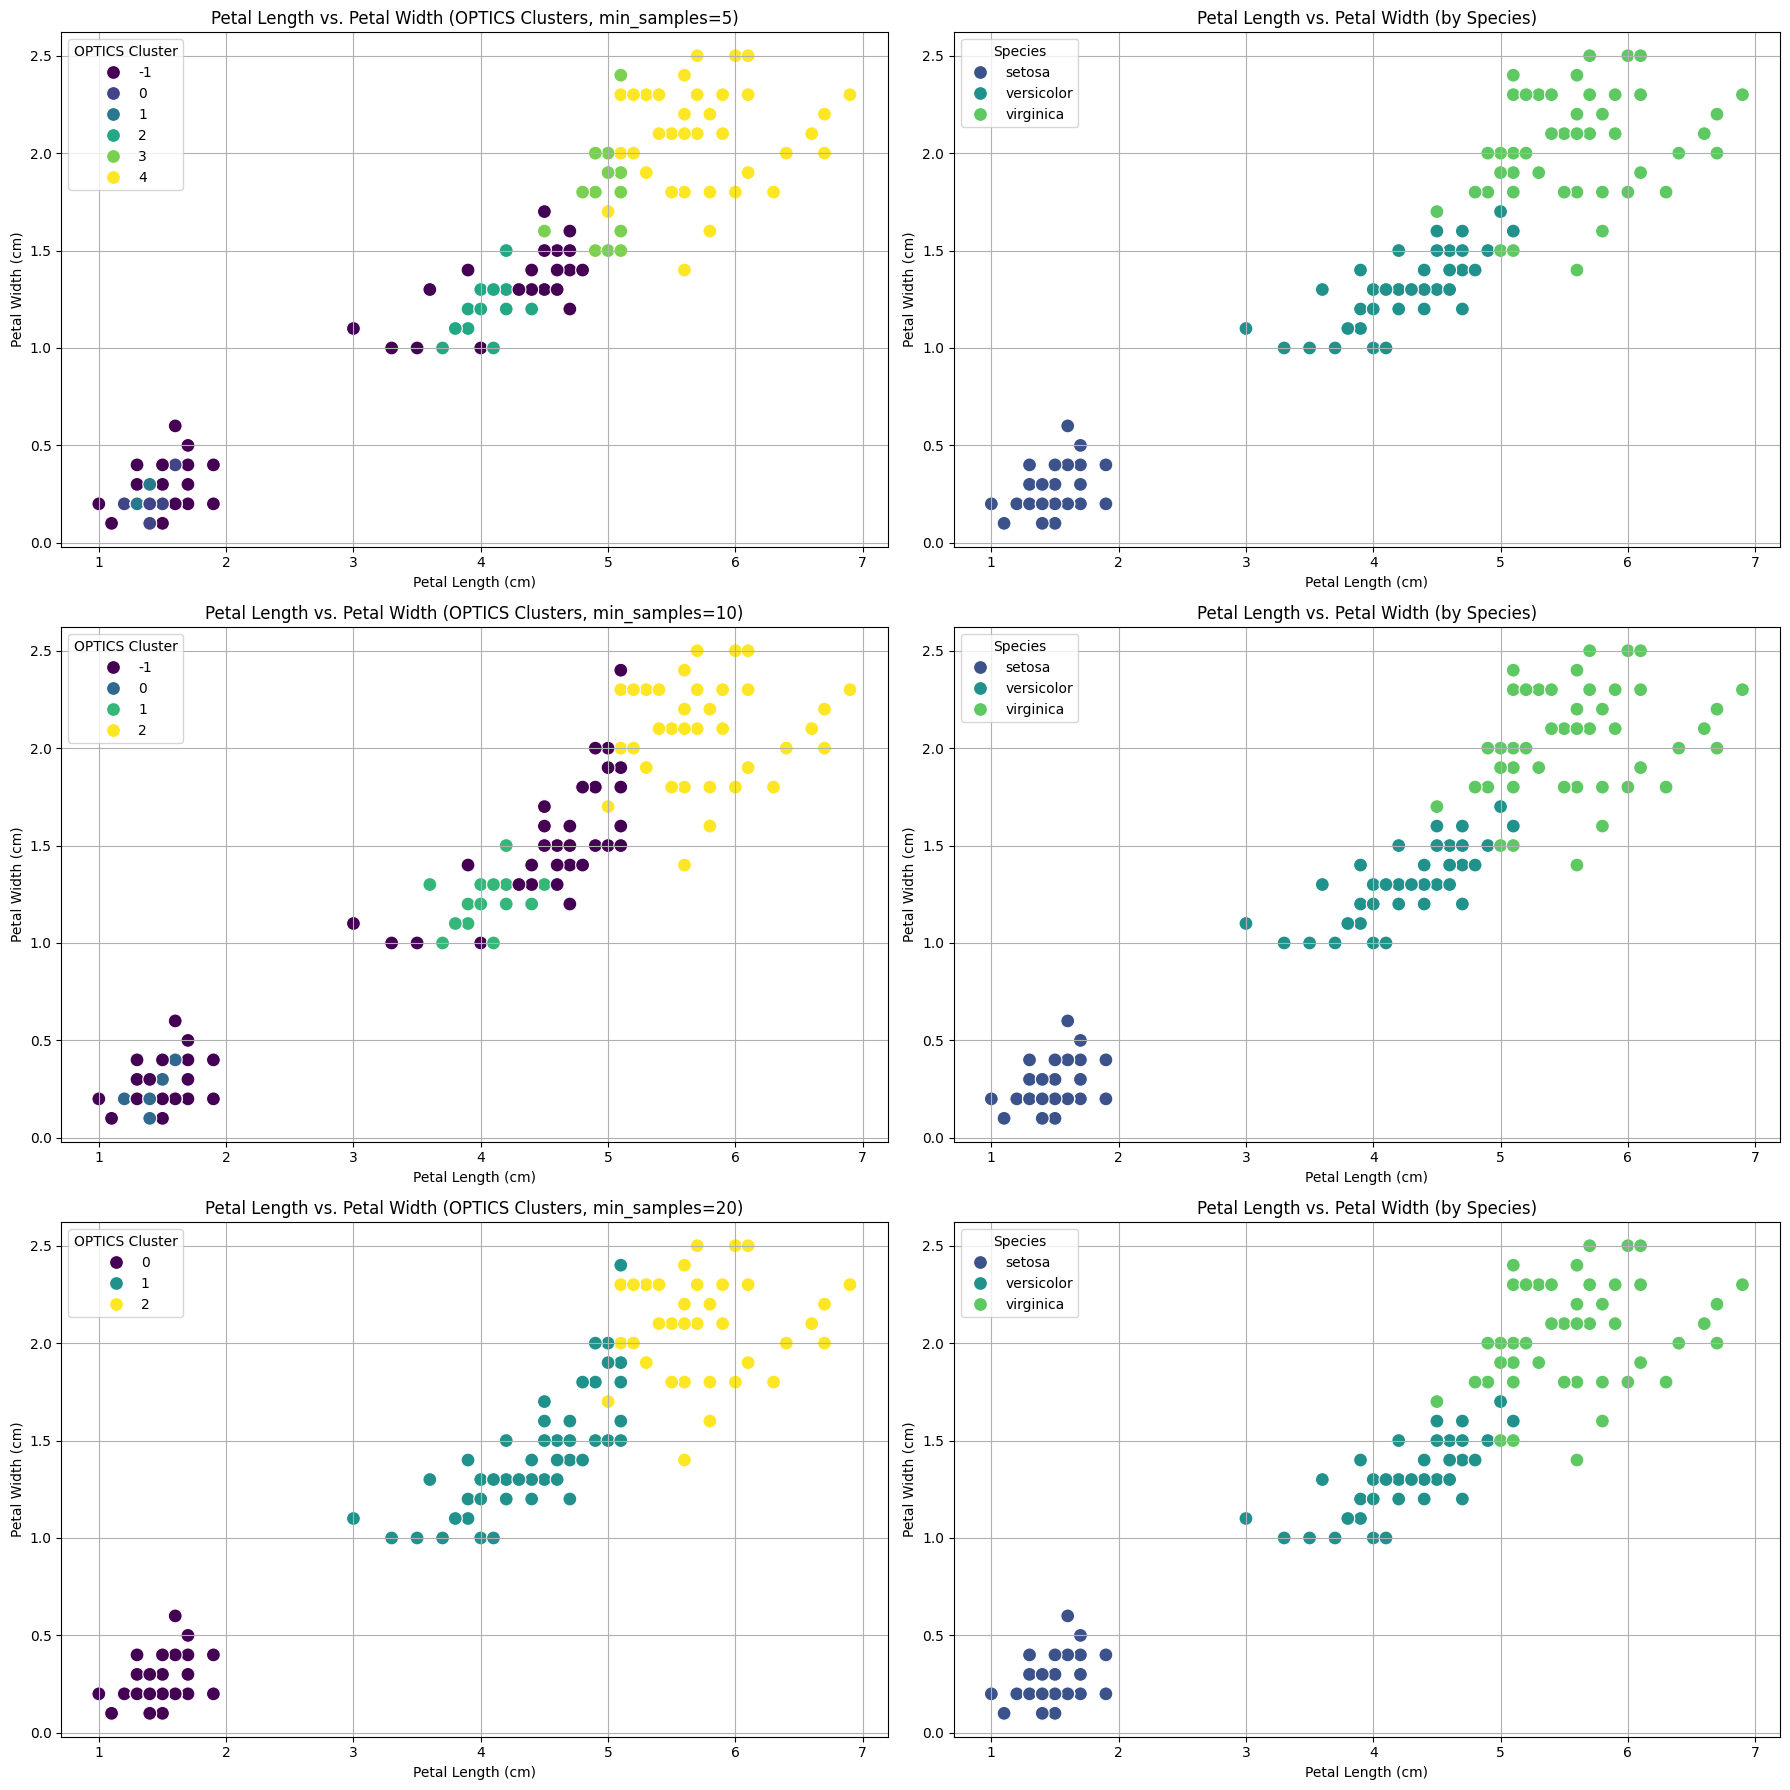

In [ ]:
from sklearn.cluster import OPTICS
import matplotlib.pyplot as plt
import seaborn as sns

# Define a range of min_samples values to test
min_samples_values = [5, 10, 20]

plt.figure(figsize=(18, 6 * len(min_samples_values)))

for i, min_samples_val in enumerate(min_samples_values):
    # Initialize and run OPTICS with the current min_samples value
    # Keep other parameters as before for now, focusing on min_samples
    clust = OPTICS(min_samples=min_samples_val, xi=0.05, min_cluster_size=0.05)
    optics_labels = clust.fit_predict(X)

    # Add OPTICS cluster labels to a temporary DataFrame for plotting
    temp_iris_df = iris_df.copy()
    temp_iris_df['optics_cluster'] = optics_labels

    # Visualize the OPTICS clustering results for the current min_samples
    plt.subplot(len(min_samples_values), 2, 2 * i + 1)
    sns.scatterplot(data=temp_iris_df, x='petal length (cm)', y='petal width (cm)', hue='optics_cluster', palette='viridis', s=100)
    plt.title(f'Petal Length vs. Petal Width (OPTICS Clusters, min_samples={min_samples_val})')
    plt.xlabel('Petal Length (cm)')
    plt.ylabel('Petal Width (cm)')
    plt.legend(title='OPTICS Cluster')
    plt.grid(True)

    # Subplot for actual species for comparison
    plt.subplot(len(min_samples_values), 2, 2 * i + 2)
    sns.scatterplot(data=temp_iris_df, x='petal length (cm)', y='petal width (cm)', hue='species', palette='viridis', s=100)
    plt.title('Petal Length vs. Petal Width (by Species)')
    plt.xlabel('Petal Length (cm)')
    plt.ylabel('Petal Width (cm)')
    plt.legend(title='Species')
    plt.grid(True)

plt.tight_layout()
plt.show()

### Discussion Questions

1.  **K-Means Sensitivity:** K-Means clustering is sensitive to which of the following parameters?
    a) The initial placement of centroids
    b) The number of clusters (k)
    c) The scale of the features
    d) All of the above

2.  **DBSCAN and Distance-Based Clustering:** How does DBSCAN's approach to defining clusters (based on density and reachability) differ fundamentally from K-Means' centroid-based approach? What are the advantages and disadvantages of each, especially concerning the need to specify the number of clusters or handle irregularly shaped clusters?

3.  **High-Dimensional Data:** Can clustering methods like K-Means, DBSCAN, or OPTICS be directly applied to raw image data (which is typically high-dimensional)? What challenges might arise, and what preprocessing steps or alternative methods might be necessary for effective clustering of images?